# Coding Session 10 · Lab W10

We keep the robocall data used earlier in the course. The goal is to read and write evaluation code, then explain what the numbers support. We use a linear-probability OLS model, matching W10 live coding.

1. Separate causal questions from prediction.
2. Hold voters back before fitting a model.
3. Compare predictions with simple baselines and actual outcomes.
4. Check probability and age-group calibration.
5. Build a practice list and audit an AI-assisted extension.

## 1. Causal inference and prediction

| Question | What the analysis needs |
| :--- | :--- |
| Does assigning robocalls change turnout? | The randomized assignment and a clearly defined causal comparison. |
| Which voters are more likely to turn out? | A predictive model evaluated on rows it did not fit. |
| Who would change their behavior if contacted? | Evidence about treatment effects, not just a turnout score. |

Good predictive performance means generalizing to unseen cases. A regression coefficient in a prediction model is an association, even when the source file comes from an experiment. This model is deliberately a coding example: it does not estimate the effect of a future door knock.

### Environment and source

Pandas handles tables, NumPy handles arrays, Matplotlib draws charts, and statsmodels fits regression. In Colab these are normally available; if an import fails, install the named package in your active notebook environment and restart that runtime.

Source: Kling, Daniel T., and Thomas Stratmann (2023), *Large-Scale Evidence for the Effectiveness of Partisan GOTV Robo Calls*, [article](https://doi.org/10.1017/XPS.2022.16). We reuse the course's existing subset; no new district voter file is needed.

| Column | Meaning in this teaching subset |
| :--- | :--- |
| `age`, `income` | Recorded age and estimated household income. |
| `male`, `svh` | Recorded binary indicators; `svh` identifies a single-voter household. |
| `gen2012` | Recorded 2012 general-election turnout. |
| `treatment`, `group` | Assignment to any treatment and assignment arm. |
| `voted` | Recorded 2014 general-election turnout. |

One row is a voter, not a household. The subset has no household identifier: this random row split cannot verify household-independent performance. Its income field is an estimate, not a directly observed resource measure.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

paths = [Path("data/kling_stratmann_subset.csv"),
         Path("wk10_turnout_models/data/kling_stratmann_subset.csv")]
local = next((p for p in paths if p.exists()), None)
source = local if local is not None else (
    "https://raw.githubusercontent.com/albertostefanelli/DSPC_coding_sessions/"
    "master/wk10_turnout_models/data/kling_stratmann_subset.csv"
)
df_kling = pd.read_csv(source)
print(df_kling.shape)
df_kling.head()

(539567, 8)


,age,income,male,svh,gen2012,treatment,group,voted
0,38.0,100000.0,1.0,0,1,1,T1: 1 Call,1
1,36.0,100000.0,0.0,0,1,1,T1: 1 Call,0
2,64.0,75000.0,1.0,0,0,0,Control (No Call),0
3,63.0,75000.0,0.0,0,0,0,Control (No Call),0
4,21.0,100000.0,0.0,0,0,0,Control (No Call),0


## 2. Inspect, split, then prepare

Missing values can make models fail or silently change the rows being evaluated. Inspect them first. We split the original row identifiers before any fitted preprocessing. Then we apply the same declared complete-case rule to each part and show how many rows it removes. No imputation or variable selection learns from the held-out outcomes.

A complete-case result applies to the retained rows. It may not generalize to voters whose covariates are missing. We omit assignment variables from the predictors; the score describes turnout in this study's mixture of conditions, not an untreated counterfactual.

In [2]:
features = ["age", "income", "male", "svh", "gen2012"]
required = features + ["voted"]
print(df_kling[required].dtypes)
print(df_kling[required].isna().sum())
train_raw = df_kling.sample(frac=0.7, random_state=10)
test_raw = df_kling.drop(train_raw.index)
train = train_raw.dropna(subset=required).copy()
test = test_raw.dropna(subset=required).copy()
assert train.index.intersection(test.index).empty
print(pd.DataFrame({"before": [len(train_raw), len(test_raw)],
                    "complete": [len(train), len(test)]},
                   index=["train", "test"]))
assert train['voted'].isin([0, 1]).all() and test['voted'].isin([0, 1]).all()

age        float64
income     float64
male       float64
svh          int64
gen2012      int64
voted        int64
dtype: object
age        21446
income     21064
male       22418
svh            0
gen2012        0
voted          0
dtype: int64
       before  complete
train  377697    361808
test   161870    154961


### Units and the regression formula

A coefficient reflects one unit of its predictor. Income measured in single currency units gives tiny-looking coefficients, so divide by 10,000 before fitting. This rescaling is fixed arithmetic, not learned preprocessing. The formula includes an intercept automatically; the lower-level `sm.OLS(Y, X)` interface instead needs a constant explicitly.

OLS on a binary outcome is a **linear-probability model**. Multiplying its coefficients by 100 expresses associations in percentage points. A small printed standard error is not an exact zero. Read the sample size and units alongside the estimates.

In [3]:
train["income_10k"] = train["income"] / 10000
test["income_10k"] = test["income"] / 10000
model = smf.ols("voted ~ age + income_10k + male + svh + gen2012", data=train).fit()
print("Fitted rows:", int(model.nobs))
pd.DataFrame({"coefficient_pp": 100 * model.params,
              "standard_error_pp": 100 * model.bse})

Fitted rows: 361808


,coefficient_pp,standard_error_pp
Intercept,-15.101483,0.294868
age,0.598563,0.004713
income_10k,0.445823,0.015370
male,3.247732,0.149261
svh,-9.780424,0.253087
gen2012,41.488060,0.185212


### Predict only on held-out rows

A straight line can leave the probability range. Inspect the raw scores before clipping them to 0–1. Clipping makes the values valid probabilities for this exercise; it does not prove that they are calibrated. Keep raw and clipped columns so this choice is visible.

Pandas attaches predictions by row index. Losing that index through an unrelated sort or reset can silently pair a prediction with the wrong outcome.

In [4]:
raw_score = model.predict(test)
assert raw_score.index.equals(test.index)
test["raw_score"] = raw_score
test["score"] = raw_score.clip(0, 1)
print("Raw range:", raw_score.min(), raw_score.max())
print("Share outside 0–1:", ((raw_score < 0) | (raw_score > 1)).mean())
test[["voted", "raw_score", "score"]].head()

Raw range: -0.11643359944723497 0.9378365000722819
Share outside 0–1: 0.011177005827272669


,voted,raw_score,score
2,0,0.297979,0.297979
4,0,0.019266,0.019266
6,0,0.676120,0.676120
10,0,0.657266,0.657266
12,1,0.549338,0.549338


## 3. Baselines, confusion, and probability scores

Accuracy is the fraction of correct 0/1 calls. Its baseline must account for the more common outcome. Choose the constant class from the **training** data, then evaluate it on the test data. Also report the test majority fraction as a descriptive floor; it is hindsight, not a trained rule.

Brier score is the mean squared difference between a probability and the binary outcome. Lower is better. Its constant-probability baseline uses the training turnout rate, not the held-out turnout rate.

In [5]:
training_rate = train["voted"].mean()
constant_class = int(training_rate >= 0.5)
test["predicted_vote"] = (test["score"] >= 0.5).astype(int)
actual = test["voted"]
accuracy = (test["predicted_vote"] == actual).mean()
constant_accuracy = (constant_class == actual).mean()
test_floor = max(actual.mean(), 1 - actual.mean())
brier_model = ((test["score"] - actual) ** 2).mean()
brier_constant = ((training_rate - actual) ** 2).mean()
pd.DataFrame({"accuracy": [accuracy, constant_accuracy],
              "Brier": [brier_model, brier_constant]},
             index=["held-out model", "training-derived constant"])

,accuracy,Brier
held-out model,0.698092,0.200840
training-derived constant,0.510019,0.249901


In [6]:
print("Descriptive test-majority floor:", round(test_floor, 3))
predicted = test["predicted_vote"]
tp = ((predicted == 1) & (actual == 1)).sum()
fp = ((predicted == 1) & (actual == 0)).sum()
fn = ((predicted == 0) & (actual == 1)).sum()
tn = ((predicted == 0) & (actual == 0)).sum()
assert tp + fp + fn + tn == len(test)
confusion = pd.DataFrame([[tn, fn], [fp, tp]],
                        index=["predict no vote", "predict vote"],
                        columns=["did not vote", "voted"])
print(confusion)
precision = tp / (tp + fp) if tp + fp else np.nan
recall = tp / (tp + fn) if tp + fn else np.nan
print("Precision:", round(precision, 3), "Recall:", round(recall, 3))

Descriptive test-majority floor: 0.51
                 did not vote  voted
predict no vote         40413  11269
predict vote            35515  67764
Precision: 0.656 Recall: 0.857


**Read the metrics.** Precision asks what fraction of predicted voters voted; recall asks what fraction of voters were identified. Calling everyone a voter buys perfect recall but says little. Confusion counts describe predictive errors, not the number of votes a campaign could gain.

**Write code:** in a new cell, use threshold 0.65 to calculate the four counts yourself, then accuracy, precision, and recall. Which quantities change, and which probability score stays unchanged? Do not refit or tune the threshold to improve this test result. If selecting a threshold for deployment, use a separate validation set and reserve a final test set.

## 4. Calibration: do probabilities mean what they say?

Of voters scored around 0.60, about 60% should vote. An upward trend alone is not sufficient: compare average prediction with actual turnout in each bin. Include bin counts; a small group is noisy. `include_lowest=True` retains exact zeros and the rightmost edge retains exact ones.

In [7]:
def calibration_table(rows):
    frame = rows[["score", "voted"]].copy()
    frame["bin"] = pd.cut(frame["score"], bins=np.linspace(0, 1, 11),
                           include_lowest=True)
    result = frame.groupby("bin", observed=True).agg(
        n=("voted", "size"), predicted=("score", "mean"), observed=("voted", "mean")
    )
    result["gap_pp"] = 100 * (result["predicted"] - result["observed"])
    assert result["n"].sum() == len(rows)
    return result

calibration = calibration_table(test)
calibration.round(3)

,n,predicted,observed,gap_pp
bin,,,,
"(-0.001, 0.1]",15278,0.047,0.104,-5.732
"(0.1, 0.2]",9149,0.147,0.138,0.856
"(0.2, 0.3]",7013,0.245,0.197,4.752
"(0.3, 0.4]",3467,0.347,0.243,10.490
"(0.4, 0.5]",16775,0.462,0.369,9.253
"(0.5, 0.6]",32047,0.556,0.546,0.995
"(0.6, 0.7]",48320,0.649,0.686,-3.703
"(0.7, 0.8]",20451,0.736,0.758,-2.175
"(0.8, 0.9]",2417,0.829,0.668,16.117


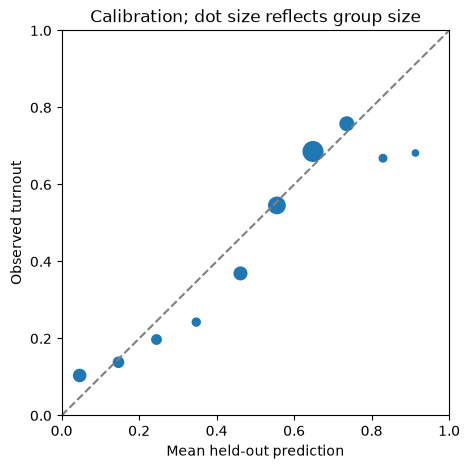

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.scatter(calibration["predicted"], calibration["observed"],
           s=20 + 180 * calibration["n"] / calibration["n"].max())
ax.set(xlabel="Mean held-out prediction", ylabel="Observed turnout",
       xlim=(0, 1), ylim=(0, 1), title="Calibration; dot size reflects group size")
plt.show()

### Group by age as well as score

Aggregate calibration can conceal errors within age groups. The age bands below cover every retained age, including extremes. A positive gap means overprediction. A prior nonvote may mean someone was not yet eligible; inspect what the recorded age and election year allow you to conclude rather than inventing birth dates.

**Write code:** reproduce this table in a new cell with your own age boundaries, using `pd.cut`, `groupby`, and named aggregation. Identify the largest absolute gap and report its group size. Explain why moving the boundaries can change the apparent worst group.

In [9]:
age_bands = pd.cut(test["age"], [-np.inf, 29, 44, 59, 74, np.inf])
by_age = test.groupby(age_bands, observed=True).agg(
    n=("voted", "size"), predicted=("score", "mean"), observed=("voted", "mean")
)
by_age["gap_pp"] = 100 * (by_age["predicted"] - by_age["observed"])
assert by_age["n"].sum() == len(test)
by_age.round(3)

,n,predicted,observed,gap_pp
age,,,,
"(-inf, 29.0]",22741,0.262,0.222,4.023
"(29.0, 44.0]",33341,0.416,0.415,0.041
"(44.0, 59.0]",55054,0.560,0.578,-1.789
"(59.0, 74.0]",32997,0.638,0.679,-4.070
"(74.0, inf]",10828,0.670,0.546,12.336


## 5. Filter, sort, and check a practice list

Use these operations to learn how a score becomes a list. A middle-score band is a choice, not evidence of greater persuadability. The file has no party column or verified later-election outcome, so it cannot reproduce the lab's party constraints or validate transfer to a new election.

The list below uses held-out rows for a transparent retrospective demonstration. Row indexes are identifiers only within this file. No real contact list is exported.

In [10]:
middle = test.loc[test["score"].between(0.35, 0.65)].copy()
capacity = min(1000, len(middle))
practice_lists = {
    "highest": test.nlargest(capacity, "score"),
    "middle": middle.sample(n=capacity, random_state=3),
    "lowest": test.nsmallest(capacity, "score"),
}
summary_rows = []
for name, rows in practice_lists.items():
    summary_rows.append({"list": name, "n": len(rows),
                         "mean_score": rows["score"].mean(),
                         "observed_turnout": rows["voted"].mean()})
pd.DataFrame(summary_rows)

,list,n,mean_score,observed_turnout
0,highest,1000,0.855844,0.632
1,middle,1000,0.557000,0.539
2,lowest,1000,0.000000,0.101


**Additional practice:** change the capacity and score interval. Before sampling, check whether the interval contains enough rows. State what to do when it does not; do not silently sample with replacement. Compare ordering with a fixed cutoff. Explain what randomized contact evidence you would need before using either rule to maximize additional turnout.



## 6. Coding with an AI agent: extend a known evaluation

Work in an approved Codex or Claude Code environment with a copy of the notebook and an environment that can run it. An agent's terminal does not automatically share Colab's files or variables. Give it code and schema first; use the small artificial check below rather than uploading voter rows.

**Prompt to adapt:**

> Extend my held-out evaluation with a training-derived constant Brier baseline and a calibration table. Preserve the split, row indexes, feature set, missing-data rule, and clipped scores. Do not fit or tune anything on test outcomes. Return a small patch and explain how exact 0 and 1 scores are counted. Check row alignment, count totals, and one hand-calculated score before suggesting interpretation.

Start from a copy with the metric additions removed. Read the patch before running it. Compare its output with the human-taught implementation above and reject any change to the evaluation sample. The agent does not decide whether the score measures causal responsiveness.

In [11]:
tiny = pd.DataFrame({"score": [0.0, 0.25, 0.75, 1.0],
                     "voted": [0, 1, 0, 1]}, index=[11, 22, 33, 44])
manual_brier = (0 + 0.75 ** 2 + 0.75 ** 2 + 0) / 4
assert np.isclose(((tiny["score"] - tiny["voted"]) ** 2).mean(), manual_brier)
assert calibration_table(tiny)["n"].sum() == 4
print("Hand check Brier:", manual_brier)

Hand check Brier: 0.28125


## Optional reference: the earlier logistic model

Logistic regression was part of an earlier version of this notebook. It is not required by the W10 lab/live coding. The aligned core above uses OLS. If revisiting logistic regression separately, keep the same train/test split and evaluate held-out probabilities; do not reuse the old in-sample chart as validation.

```python
optional_model = smf.logit(
    "voted ~ age + income_10k + male + svh + gen2012", data=train
).fit()
optional_scores = optional_model.predict(test)
```

Logistic coefficients are changes in log odds. Exponentiating gives an odds ratio, which is not a probability difference or a causal effect. Scaling income still changes the unit of interpretation. This optional snippet is not run as part of the lesson.

**Before leaving:** restart and run the notebook in order. Explain the training constant, one calibration gap, and one limit of the practice list without asking an agent to choose your conclusion.